```
# =============================================================================
# Integrantes: Arthur Meneses Neves, Danilo Oliveira Santos, Matheus Gabriel
# Viana Araujo, João Victor Vidal Barbosa, Guilherme Araujo Castro
#
# Síntese: Preparação dos dados do SIM 2000-2026 para modelagem: idade, escolaridade e
# raça/cor harmonizadas, UF derivada do município, alvo (capítulo CID-10) e
# filtros com contagem de linhas. A lógica está em src/sim_utils.py; aqui ela é
# executada e documentada. Inclui a discussão de ética (LGPD, vazamento de
# rótulo, viés, CEP).
#
# Changelog:
#   2026-09-23 - Matheus Araujo - criação do notebook
#   2026-09-23 - Matheus Araujo - seção de aspectos éticos
#   2026-09-24 - Matheus Araujo - correção sobre células pequenas na seção de ética
#   2026-09-24 - Matheus Araujo - ajuste de texto da seção 6
# =============================================================================
```

# Preparação dos dados para modelagem

O notebook `01_eda_exploratoria.ipynb` mostrou que o SIM 2000-2026 tem várias inconsistências entre anos. Aqui elas são tratadas por **uma única função**, `sim_utils.preparar_df_modelo`, que os notebooks de modelagem também importam (há uma só definição das variáveis). O resultado é lido por `sim_utils.carregar_df_modelo`, que guarda um cache Parquet em `data/cache/` (não versionado). A chave do cache combina os anos, o tamanho e a data de modificação de cada CSV e a constante `PREP_VERSION`, então um cache desatualizado nunca é usado sem aviso.

**Variáveis de entrada do modelo (features):** `idade_anos`, `sexo`, `racacor`, `escolaridade`, `uf` (unidade da federação derivada do município de residência). `codmun6` (município com 6 dígitos) fica no quadro só para análises agregadas.
**Alvo:** `capitulo_cid10` (capítulo da CID-10 da causa básica, `CAUSABAS`). Nenhum campo que revele a causa (`LINHAA`-`LINHAD`, `CIRCOBITO`, `CAUSABAS_O`) é carregado: `CORE_COLUMNS` só traz `TIPOBITO`, `DTOBITO`, `IDADE`, `SEXO`, `RACACOR`, `ESC`, `CODMUNRES` e `CAUSABAS`.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
import sim_utils
from sim_utils import carregar_df_modelo, tabela_mapeamento

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

ANOS = list(range(2000, 2027))  # 1979-1999 fora de escopo (CID-9)
chave = sim_utils._chave_cache("../data", ANOS)
arquivo_cache = Path("../data/cache") / f"df_modelo_{chave}.parquet"
havia_cache = arquivo_cache.exists()

t0 = time.perf_counter()
df_modelo = carregar_df_modelo("../data", ANOS, "../data/cache")
segundos = time.perf_counter() - t0
diag = df_modelo.attrs["diagnosticos"]

print(f"PREP_VERSION: {sim_utils.PREP_VERSION}")
print(f"Arquivo de cache: {arquivo_cache.name} (existia antes desta execução: {havia_cache})")
print(f"Carga: {segundos:.1f} s  ->  {'lido do cache' if havia_cache else 'construído a partir dos CSVs'}")
print(f"Formato: {df_modelo.shape[0]:,} linhas x {df_modelo.shape[1]} colunas")

PREP_VERSION: 1
Arquivo de cache: df_modelo_5f531793d01f7a1b.parquet (existia antes desta execução: False)
Carga: 121.8 s  ->  construído a partir dos CSVs
Formato: 32,531,918 linhas x 8 colunas


## 1. Escolaridade (ESC) e raça/cor (RACACOR): distribuição bruta por ano

Contagens brutas (antes de qualquer mapeamento), incluindo `NaN`. Os valores `1` e `1.0` (texto em 2000-2001, número nos demais anos) já aparecem unificados. Os valores raros como `A` e `8` também estão na tabela.

In [2]:
esc_bruto = pd.DataFrame(diag["esc_bruto_por_ano"]).T.fillna(0).astype(int)
esc_bruto.index.name = "ano_arquivo"
esc_bruto = esc_bruto[sorted(esc_bruto.columns)]
print("ESC bruto: contagem por ano (colunas = valor bruto)")
print(esc_bruto.to_string())
print()
print("ESC bruto: % por ano")
print((100 * esc_bruto.div(esc_bruto.sum(axis=1), axis=0)).round(2).to_string())

ESC bruto: contagem por ano (colunas = valor bruto)
                 0       1       2       3       4       5    8       9   A     NaN
ano_arquivo                                                                        
2000             0  176779  165468  114045   45555   27159  104  232395  65  185116
2001             0  176260  175551  121801   48675   29231   82  232460  41  177391
2002             0  184688  182312  132752   53442   31942    0  232786   0  164885
2003             0  186543  185916  141216   58407   33688    0  167789   0  228781
2004             0  186865  193606  152207   64567   36417    0  165638   0  224773
2005             0  179023  187073  153982   67502   37117    0  170470   0  211660
2006             0  154500  189567  166994   74670   40526    0  171886   0  233548
2007             0  157060  193685  179192   82519   41846    0  168022   0  225500
2008             0  162970  201771  195000   88666   44974    0  163830   0  219796
2009            14  1649

In [3]:
raca_bruto = pd.DataFrame(diag["racacor_bruto_por_ano"]).T.fillna(0).astype(int)
raca_bruto.index.name = "ano_arquivo"
raca_bruto = raca_bruto[sorted(raca_bruto.columns)]
print("RACACOR bruto: contagem por ano (colunas = valor bruto)")
print(raca_bruto.to_string())
print()
print("RACACOR bruto: % por ano")
print((100 * raca_bruto.div(raca_bruto.sum(axis=1), axis=0)).round(2).to_string())

RACACOR bruto: contagem por ano (colunas = valor bruto)
                  1       2      3       4     5  9     NaN
ano_arquivo                                                
2000         498996   62045  10373  222424  2285  0  150563
2001         517710   65420   6098  238274  1991  0  131999
2002         532052   67703   5246  257995  2054  0  117757
2003         547000   72526   6040  271341  2095  0  103338
2004         559828   74246   6235  285162  2246  0   96356
2005         546825   71831   5773  294251  2352  0   85795
2006         552309   73700   5502  306790  2614  0   90776
2007         560228   74859   5218  320251  2623  0   84645
2008         570472   77954   5488  340629  2820  0   79644
2009         580842   78667   5659  355804  3007  0   79109
2010         597920   84284   6165  372646  2927  0   73005
2011         612252   90789   6867  387718  3053  0   69819
2012         610195   89572   6531  406166  3406  0   65296
2013         621490   90728   6673  420899  

## 2. Mapeamento único adotado

**Escolaridade (`ESC_MAP`).** Segue o dicionário do SIM: 1 = Nenhuma, 2 = 1 a 3 anos, 3 = 4 a 7 anos, 4 = 8 a 11 anos, 5 = 12 anos ou mais. Tudo o mais vira `"Ignorado"`: o código 9 (ignorado no próprio SIM), `NaN`, os textos `A` e `8` (raros, só em 2000-2001) e o código 0 (aparece só em alguns anos e não consta no dicionário de ESC).

**Raça/cor (`RACACOR_MAP`).** 1 = Branca, 2 = Preta, 3 = Amarela, 4 = Parda, 5 = Indígena. Qualquer outro valor, inclusive 9 e `NaN`, vira `"Ignorado"`.

Nenhuma linha é descartada por ESC ou RACACOR ignorados. "Ignorado" é uma categoria explícita: ESC ignorado ou ausente (9 + `NaN`) chega a 44% em 2000 e soma 26% do total, e RACACOR ausente vai de 15,9% em 2000 a 1,2% em 2026, então descartar essas linhas enviesaria a amostra e os anos iniciais seriam os mais afetados. O código 0 de ESC aparece só em 2009-2012 e 2014 (0,7% do total) e também vira "Ignorado"; se o grupo preferir tratá-lo como "Nenhuma", basta alterar `ESC_MAP` e incrementar `PREP_VERSION`.

As tabelas abaixo mostram, sobre todos os registros brutos, quantos registros cada valor bruto contribui para cada categoria mapeada.

In [4]:
mapa_esc = tabela_mapeamento(diag["esc_bruto_por_ano"], sim_utils.ESC_MAP)
print("ESC: valor bruto -> categoria (todos os anos, antes dos filtros)")
print(mapa_esc.round(3).to_string())
print()
print("ESC: total por categoria mapeada")
print(mapa_esc.groupby("mapeado", sort=False)[["n", "pct"]].sum().round(3).to_string())

ESC: valor bruto -> categoria (todos os anos, antes dos filtros)
  bruto        n   mapeado     pct
0     5  1610861   12+anos   4.937
1     2  6655945   1a3anos  20.399
2     3  6283348   4a7anos  19.257
3     4  4204967  8a11anos  12.887
4     0   231933  Ignorado   0.711
5     8      186  Ignorado   0.001
6     9  4412340  Ignorado  13.523
7     A      106  Ignorado   0.000
8   NaN  3972381  Ignorado  12.174
9     1  5257004   Nenhuma  16.111

ESC: total por categoria mapeada
                n     pct
mapeado                  
12+anos   1610861   4.937
1a3anos   6655945  20.399
4a7anos   6283348  19.257
8a11anos  4204967  12.887
Ignorado  8616946  26.409
Nenhuma   5257004  16.111


In [5]:
mapa_raca = tabela_mapeamento(diag["racacor_bruto_por_ano"], sim_utils.RACACOR_MAP)
print("RACACOR: valor bruto -> categoria (todos os anos, antes dos filtros)")
print(mapa_raca.round(3).to_string())
print()
print("RACACOR: total por categoria mapeada")
print(mapa_raca.groupby("mapeado", sort=False)[["n", "pct"]].sum().round(3).to_string())

RACACOR: valor bruto -> categoria (todos os anos, antes dos filtros)
  bruto         n   mapeado     pct
0     3    192967   Amarela   0.591
1     1  16889989    Branca  51.764
2     9         5  Ignorado   0.000
3   NaN   1758233  Ignorado   5.389
4     5     95573  Indígena   0.293
5     4  11157986     Parda  34.196
6     2   2534318     Preta   7.767

RACACOR: total por categoria mapeada
                 n     pct
mapeado                   
Amarela     192967   0.591
Branca    16889989  51.764
Ignorado   1758238   5.389
Indígena     95573   0.293
Parda     11157986  34.196
Preta      2534318   7.767


## 3. Filtros e contabilidade de linhas

Três filtros, aplicados em sequência:

1. `SEXO` fora de {1, 2}: o código 0 (ignorado) não é `NaN`, então precisa ser filtrado por valor.
2. `IDADE` ignorada ou ausente (000, 999, `NaN`): sem idade não há feature.
3. `CAUSABAS` sem capítulo CID-10 (ausente ou código fora do escopo CID-10, por exemplo CID-9): sem alvo não há exemplo.

`TIPOBITO` não é usado como filtro. A última linha da saída mostra a contagem por `TIPOBITO` (1 = fetal, 2 = não fetal) no quadro final: só há óbitos não fetais.

In [6]:
c = diag["contabilidade"]
etapas = [
    ("Registros brutos (27 CSVs, 2000-2026)", c["n_bruto"], 0),
    ("Após SEXO in {1, 2}", c["n_apos_sexo"], c["descartados_sexo"]),
    ("Após IDADE conhecida", c["n_apos_idade"], c["descartados_idade"]),
    ("Após CAUSABAS com capítulo CID-10", c["n_apos_capitulo"], c["descartados_capitulo"]),
]
contab = pd.DataFrame(etapas, columns=["etapa", "linhas_restantes", "descartadas_na_etapa"])
contab["% do bruto descartado na etapa"] = (100 * contab["descartadas_na_etapa"] / c["n_bruto"]).round(4)
print(contab.to_string(index=False))
total_desc = c["n_bruto"] - c["n_final"]
print()
print(f"Total descartado: {total_desc:,} de {c['n_bruto']:,} ({100 * total_desc / c['n_bruto']:.4f}%)")
print(f"Linhas finais: {c['n_final']:,}  (confere com len(df_modelo) = {len(df_modelo):,}: {c['n_final'] == len(df_modelo)})")
print()
print("TIPOBITO das linhas finais (1 = fetal, 2 = não fetal):", diag.get("tipobito_final"))

                                etapa  linhas_restantes  descartadas_na_etapa  % do bruto descartado na etapa
Registros brutos (27 CSVs, 2000-2026)          32629071                     0                          0.0000
                  Após SEXO in {1, 2}          32613229                 15842                          0.0486
                 Após IDADE conhecida          32531921                 81308                          0.2492
    Após CAUSABAS com capítulo CID-10          32531918                     3                          0.0000

Total descartado: 97,153 de 32,629,071 (0.2977%)
Linhas finais: 32,531,918  (confere com len(df_modelo) = 32,531,918: True)

TIPOBITO das linhas finais (1 = fetal, 2 = não fetal): {'2': 32531918}


## 4. Quadro de modelagem

Tipos de dados, nulos por coluna e primeiras linhas. As colunas categóricas usam o dtype `category` para poupar memória (o quadro tem dezenas de milhões de linhas).

In [7]:
print(df_modelo.dtypes.to_string())
print()
print("Nulos por coluna:")
print(df_modelo.isna().sum().to_string())
print()
print(f"Memória: {df_modelo.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print()
print(df_modelo.head(8).to_string())
print()
print("idade_anos:")
print(df_modelo["idade_anos"].describe().round(2).to_string())

idade_anos           int16
sexo              category
racacor           category
escolaridade      category
uf                category
codmun6              Int32
ano_arquivo          int16
capitulo_cid10    category

Nulos por coluna:
idade_anos        0
sexo              0
racacor           0
escolaridade      0
uf                0
codmun6           0
ano_arquivo       0
capitulo_cid10    0



Memória: 0.46 GB

   idade_anos       sexo   racacor escolaridade  uf  codmun6  ano_arquivo capitulo_cid10
0          23   Feminino    Branca      4a7anos  AC   120040         2000             XX
1           0   Feminino  Ignorado      Nenhuma  AC   120080         2000          XVIII
2           0  Masculino    Branca     Ignorado  AC   120060         2000          XVIII
3          91  Masculino    Branca      1a3anos  AC   120060         2000          XVIII
4          95   Feminino    Branca      Nenhuma  AC   120060         2000          XVIII
5          71  Masculino     Parda      1a3anos  AC   120060         2000          XVIII
6          91   Feminino    Branca      1a3anos  AC   120060         2000          XVIII
7          78  Masculino     Parda      Nenhuma  AC   120060         2000          XVIII

idade_anos:


count    32531918.00
mean           63.19
std            23.33
min             0.00
25%            51.00
50%            68.00
75%            80.00
max           133.00


## 5. UF derivada do município de residência

`CODMUNRES` mistura códigos IBGE de 6 e 7 dígitos (por exemplo, `355030` e `3550308` são ambos São Paulo). Ele é truncado a 6 dígitos (`codmun6`) e a UF é obtida pelos 2 primeiros. O modelo usa **`uf`**, não o município: cerca de 5.500 municípios inviabilizam o one-hot e aumentam o risco de reidentificação em células pequenas. Município inválido (código fora das 27 UFs ou ausente) vira `uf = "Ignorado"` e `codmun6` nulo.

In [8]:
uf_cont = df_modelo["uf"].value_counts()
uf_tab = pd.DataFrame({"n": uf_cont, "pct": (100 * uf_cont / len(df_modelo)).round(3)})
print(f"Categorias de uf: {df_modelo['uf'].cat.categories.size} "
      f"({(uf_tab.index != 'Ignorado').sum()} UFs válidas + 'Ignorado' se presente)")
print(uf_tab.to_string())
print()
print(f"codmun6 nulos (município inválido/ausente): {df_modelo['codmun6'].isna().sum():,}")
print(f"Municípios distintos (codmun6): {df_modelo['codmun6'].nunique():,}")

Categorias de uf: 27 (27 UFs válidas + 'Ignorado' se presente)
          n     pct
uf                 
SP  7545950  23.196
RJ  3485771  10.715
MG  3394465  10.434
RS  2189971   6.732
BA  2178391   6.696
PR  1876192   5.767
PE  1592547   4.895
CE  1341560   4.124
SC  1011898   3.110
GO   951470   2.925
PA   922912   2.837
MA   804966   2.474
PB   661684   2.034
ES   596564   1.834
AL   498694   1.533
RN   491192   1.510
PI   475272   1.461
MT   443649   1.364
AM   414286   1.273
MS   409083   1.257
SE   319215   0.981
DF   311523   0.958
RO   207060   0.636
TO   185483   0.570
AC    90923   0.279
AP    74319   0.228
RR    56878   0.175

codmun6 nulos (município inválido/ausente): 0


Municípios distintos (codmun6): 5,600


## 6. Distribuição final das classes (alvo `capitulo_cid10`)

Os capítulos foram mantidos como estão, sem fundir os raros. A tabela mostra o desbalanceamento, que os modelos e as métricas (F1-macro, recall por classe) precisam considerar.

In [9]:
desc = {n: d for n, _, _, d in sim_utils._CHAPTER_RANGES}
cls = df_modelo["capitulo_cid10"].value_counts()
cls_tab = pd.DataFrame({
    "capitulo": cls.index.astype(str),
    "descricao": [desc[str(i)] for i in cls.index],
    "n": cls.values,
    "pct": (100 * cls.values / len(df_modelo)).round(4),
})
cls_tab["razao_maior/classe"] = (cls.iloc[0] / cls_tab["n"]).round(1)
print(f"Classes (capítulos CID-10) observadas: {cls.size}")
ausentes = [n for n, _, _, _ in sim_utils._CHAPTER_RANGES if n not in set(cls_tab["capitulo"])]
print(f"Capítulos que nunca ocorrem como causa básica: {ausentes}")
print(cls_tab.to_string(index=False))
print()
print(f"Maior classe: {cls_tab.iloc[0]['capitulo']} = {cls_tab.iloc[0]['pct']}%")
print(f"Menor classe: {cls_tab.iloc[-1]['capitulo']} = {cls_tab.iloc[-1]['pct']}% ({cls_tab.iloc[-1]['n']:,} registros)")
print(f"Razão maior/menor: {cls.iloc[0] / cls.iloc[-1]:,.0f}x")
print(f"Classes com menos de 0,5% dos registros: {(cls_tab['pct'] < 0.5).sum()}")

Classes (capítulos CID-10) observadas: 19
Capítulos que nunca ocorrem como causa básica: ['XIX', 'XXI']
capitulo                                                          descricao       n     pct  razao_maior/classe
      IX                                   Doenças do aparelho circulatório 8788199 27.0141                 1.0
      II                                               Neoplasias (tumores) 5108490 15.7030                 1.7
      XX                         Causas externas de morbidade e mortalidade 3712335 11.4114                 2.4
       X                                   Doenças do aparelho respiratório 3516512 10.8094                 2.5
   XVIII          Sintomas, sinais e achados anormais, causas mal definidas 2328478  7.1575                 3.8
       I                                 Doenças infecciosas e parasitárias 2108449  6.4812                 4.2
      IV                     Doenças endócrinas, nutricionais e metabólicas 1896126  5.8285                 4.6


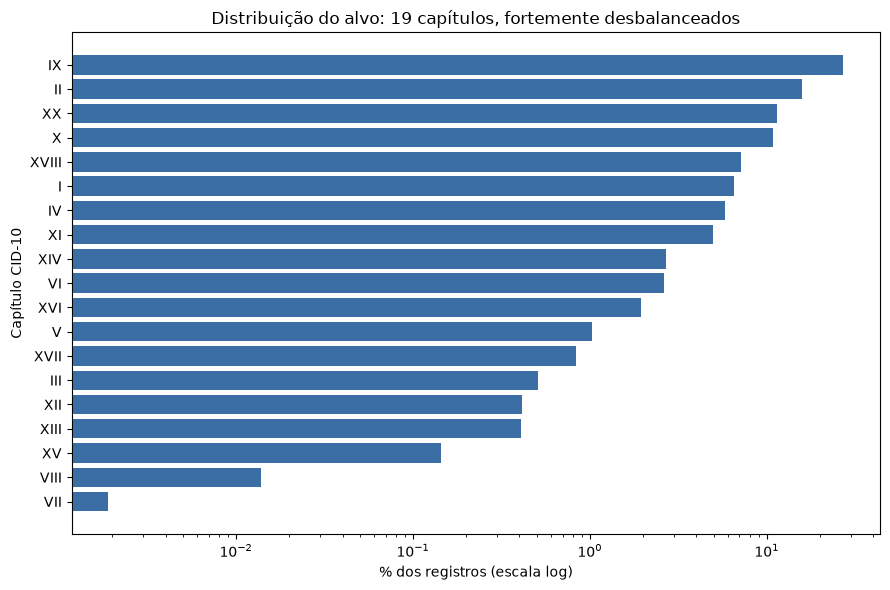

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
ordem = cls_tab.iloc[::-1]
ax.barh(ordem["capitulo"], ordem["pct"], color="#3b6ea5")
ax.set_xscale("log")
ax.set_xlabel("% dos registros (escala log)")
ax.set_ylabel("Capítulo CID-10")
ax.set_title("Distribuição do alvo: 19 capítulos, fortemente desbalanceados")
plt.tight_layout()
plt.show()

## Reprodutibilidade

`df_modelo` não é versionado. O cache em `data/cache/` (Parquet mais um `.json` com os diagnósticos usados acima) está no `.gitignore`. A primeira execução constrói o cache lendo os 27 CSVs; as seguintes leem o Parquet em segundos. Se a lógica de preparação ou de leitura mudar, `PREP_VERSION` em `src/sim_utils.py` deve ser incrementada. Os notebooks de modelagem chamam a mesma `carregar_df_modelo`.

## Aspectos éticos e responsabilidade no uso da IA

- **Privacidade e LGPD.** Os dados são os microdados públicos do SIM, abertos pelo Ministério da Saúde (licença CC-BY) e usados como foram publicados. O projeto lê 8 colunas (`CORE_COLUMNS`) e nenhuma é identificador direto (nome, CPF, endereço). Ainda assim, idade, município e data do óbito juntos podem permitir reidentificação em municípios pequenos ou em causas raras. Para reduzir esse risco e respeitar a LGPD e os termos de uso do DATASUS, o grupo adota:
  - só dados públicos e anonimizados, sem tentar reidentificar ninguém e sem cruzar com outras bases;
  - minimização de atributos: cinco variáveis nos modelos, e o município entra só como UF (`codmun6` fica no quadro apenas para análises agregadas). `DTOBITO` é lido, mas o quadro de modelagem guarda só o ano do arquivo;
  - supressão de grupos pequenos: célula de resultado com menos de 10 casos não será publicada (artigo, dashboard), por exemplo em cruzamentos UF×capítulo ou município×capítulo. É uma regra adotada pelo grupo e ainda não está implementada em código.

  Hoje nenhum resultado publicado (métricas por classe e por ano, matrizes de confusão) tem célula abaixo desse limite: a menor classe (capítulo VII) tem 629 registros, o menor suporte de teste é 126 linhas e a menor UF (RR) tem 56.878 registros. As tabelas dos notebooks 01 e 02 são material de diagnóstico, não resultado publicado. Nelas, as únicas contagens abaixo de 10 são `RACACOR` = 9 (5 vezes no período) e as 3 linhas sem capítulo CID-10, que são contagens nacionais de uma variável só.
- **Arquivos de dados.** Os CSVs brutos (`data/*.csv`) e o cache Parquet (`data/cache/`) estão no `.gitignore`. O repositório público tem só o código, os resultados agregados e a documentação, com a origem dos dados e como obtê-los.
- **Vazamento de rótulo.** O SIM tem campos que descrevem a cadeia de causas do próprio atestado (`LINHAA` a `LINHAD`, `CIRCOBITO`, `CAUSABAS_O`). Usá-los como entrada seria entregar ao modelo o que ele deveria prever. Por isso `CORE_COLUMNS` carrega só 8 colunas (`TIPOBITO`, `DTOBITO`, `IDADE`, `SEXO`, `RACACOR`, `ESC`, `CODMUNRES`, `CAUSABAS`) e esses campos nem chegam a ser lidos. As entradas (`FEATURE_COLUMNS`) são idade, sexo, raça/cor, escolaridade e UF. O notebook 03 confere isso com asserções: nenhuma entrada é o rótulo, `CAUSABAS`, `CAUSABAS_O`, `CIRCOBITO`, `codmun6` ou `ano_arquivo`, e nenhuma coluna `LINHA*` está no quadro de modelagem.
- **Viés dos dados.** `RACACOR` e `ESC` têm muitos valores ignorados ou ausentes, e isso varia bastante entre os anos. Em todo o período, `RACACOR` "Ignorado" soma 5,389% (1.758.238 registros; 15,90% em 2000 e 1,23% em 2026) e `ESC` "Ignorado" soma 26,409% (8.616.946 registros). Em `ESC` o problema pesa mais nos anos iniciais: o código 9 mais os ausentes chegam a 44,1% em 2000 e caem para 14,2% em 2025. Um modelo treinado assim herda qualquer padrão sistemático desse não-preenchimento (por exemplo, se a ausência for mais comum em certos serviços de saúde ou regiões, o que não foi medido). Por isso mantemos "Ignorado" como categoria explícita, em vez de imputar valores, e nenhuma linha é descartada por `ESC` ou `RACACOR` ignorados. **Limitação:** o código 0 de `ESC` aparece só em 2009 a 2012 e 2014 (231.933 registros, 0,711%) e não está no dicionário do SIM. Foi mapeado para "Ignorado", mas poderia significar "Nenhuma"; a escolha está em `ESC_MAP` e pode ser revista.
- **Uso pretendido e mau uso.** O objetivo é apoiar o planejamento em saúde pública, como a priorização de recursos a partir do padrão regional de causas de óbito. O modelo não deve ser usado para decisões individuais sobre pessoas vivas nem para inferir a causa de uma morte específica sem o laudo médico, que é a fonte de verdade.
- **Transparência.** O alvo é o capítulo da CID-10, não o código completo, como orientou o professor no parecer da Parte 1. Além de evitar centenas de classes, isso dá uma categoria ampla e fácil de auditar, o que reduz o risco de decisões automáticas muito específicas a partir de poucas variáveis.
- **Comitê de Ética (CEP).** O projeto usa só dados públicos, secundários e anonimizados, sem acesso a registros identificáveis, sem cruzar com outras bases e sem contato com pessoas. Pelo parecer do professor na Parte 1, isso provavelmente dispensa submissão ao CEP, e o grupo conclui o mesmo. Isso mudaria se o projeto passasse a usar registros identificáveis ou de acesso restrito, cruzasse o SIM com outra base ou envolvesse contato direto com pessoas. Nada disso ocorre hoje; se ocorrer, a necessidade do CEP deve ser reavaliada antes de seguir.
- **Limitações e próximos passos.** (a) Ainda não há análise de erro por subgrupo (raça/cor, sexo, UF), prevista para a N2. (b) O modelo é fraco: o F1-macro é 0,1329 (Random Forest) e 0,1406 (XGBoost), contra 0,0224 do baseline, e a acurácia (0,1625 e 0,1755) fica abaixo da do baseline (0,2701). Por isso não serve para decisões individuais. (c) Os pesos balanceados trocam acurácia nas classes frequentes por recall nas raras: o recall do capítulo IX (circulatório) cai a 0,0013 no Random Forest e 0,0260 no XGBoost. É uma escolha de valor que deveria ser revista com interessados da saúde pública.